# Inference Speed — Prompt U-Net vs nnInteractive (3D)

Compares inference time for both models on small and large 3D volumes.

**Size classification** (different for each model's bottleneck):
- **Small**: ROI in-plane bounding-box extent ≤128 in both axes (P-UNet single-tile regime, no tiling overhead)
- **Large**: total_voxels > 192³ = 7,077,888 (nnInteractive patch size, AutoZoom required)

These are NOT complementary bins. A volume can be both, neither, or either.
See §2 for details.

| Section | Content |
|---------|--------|
| **§1** | Load results PKL — extract timing per run |
| **§2** | Compute ROI in-plane bbox from NPZ — classify Small / Large |
| **§3** | Scatter plot — time vs total_voxels, colored by model |
| **§4** | Timing table — avg ± std per model per bin |
| **§5** | Memory reference — nnInteractive paper VRAM values |
| **Appendix** | Per-dataset timing breakdown |

---
## §1 — Load Results PKL

In [1]:
import sys, pickle
from pathlib import Path

notebook_dir = Path().resolve()
project_root = notebook_dir.parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style="whitegrid", context="paper")

In [2]:
PKL_PATH = "results_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_135822.pkl"

print(f'Loading: {PKL_PATH}')
with open(PKL_PATH, 'rb') as f:
    records = pickle.load(f)
print(f'Loaded {len(records)} runs')

Loading: results_p_unet_332_ssf_none_ifl_ssf_ConfidenceDrop_df0.05_20260520_135822.pkl
Loaded 1432 runs


In [3]:
# Extract timing rows — one row per (volume, run, model, mode)
rows = []
for r in records:
    base = {
        'volume_id'   : r['volume_id'],
        'pid'         : r['pid'],
        'run_idx'     : r['run_idx'],
        'dataset_name': r['dataset_name'],
        'selected_roi': r.get('selected_roi', 0),
        'modality'    : r.get('modality', 'ct'),
        'prompt_axis' : r['prompt_axis'],
        'roi_slices'  : r.get('roi_slices', 0),
        'roi_voxels'  : r.get('roi_voxels', 0),
    }
    for mode, md in r.get('per_mode', {}).items():
        rows.append({**base, 'model': 'P-UNet', 'mode': mode, 'time_s': md['time_s']})
    for nn_key, nn_md in r.get('nn_results', {}).items():
        rows.append({**base, 'model': 'nnInteractive', 'mode': nn_key, 'time_s': nn_md['time_s']})

df = pd.DataFrame(rows)
print(f'{len(df)} timing rows')
print(f'Models: {sorted(df["model"].unique())}')
print(f'Modes:  {sorted(df["mode"].unique())}')

7160 timing rows
Models: ['P-UNet', 'nnInteractive']
Modes:  ['baseline', 'ifl_ssf', 'none', 'ssf']


---
## §2 — Compute ROI In-Plane Bbox from NPZ & Classify

### What we compute
For each unique `(dataset_name, pid, selected_roi, prompt_axis)` combination we:

1. Load the 3D ground-truth segmentation from the original `.npz` file (mmap, no image data loaded).
2. Isolate the binary mask of the single ROI that was benchmarked in this run.
3. For each slice along `prompt_axis` where the ROI is present, compute the 2D `(min_row, max_row, min_col, max_col)` bounding box of the foreground pixels.
4. Take the **maximum width and maximum height** across all slices. This is the ROI’s full in-plane spatial extent — the tightest 2D rectangle that encloses the structure in any slice.
5. `max_bbox_extent = max(max_h, max_w)`.

### Classification
- **Small** : `max_bbox_extent ≤ 128` — the ROI never exceeds 128 px in either in-plane axis, so P-UNet’s tiling module always processes it with a single 128×128 tile (zero tiling overhead).
- **Large** : `total_voxels > 192³` — the image volume exceeds nnInteractive’s 3D patch, forcing AutoZoom.

A volume can be neither (in-between), both (many thin slices each ≤128 but >192³ total), or either.

In [4]:
NPZ_PATHS = [
    project_root / 'data' / 'test_data' / 'TotalSeg_mri.npz',
    project_root / 'data' / 'test_data' / 'FLARE_2022.npz',
    project_root / 'data' / 'test_data' / 'han_seg_ct.npz',
    project_root / 'data' / 'test_data' / 'han_seg_mri.npz',
    project_root / 'data' / 'test_data' / 'SegRap2023.npz',
    project_root / 'data' / 'test_data' / 'HCCTase_ceCT.npz',
]

# ------------------------------------------------------------------
# Pre-index every NPZ: open each file once, build pid→idx and pid→shape maps.
# File handles stay open (mmap_mode='r'); no image data is loaded.
# ------------------------------------------------------------------
_NPZ_DATA = {}       # dataset_name → opened npz
_PID_IDX  = {}        # (dataset_name, pid) → int index
_PID_SHAPE = {}       # (dataset_name, pid) → (D0, D1, D2)
_PID_SEG_COUNT = {}   # (dataset_name, pid) → int
pid_resolution = {}   # (pid, axis) → (H, W)  — also built here for total_voxels

print('Indexing NPZ files ...')
for npz_path in NPZ_PATHS:
    ds_name = npz_path.stem
    data = np.load(str(npz_path), allow_pickle=False, mmap_mode='r')
    _NPZ_DATA[ds_name] = data
    for i, p in enumerate(data['_pids']):
        p = str(p)
        _PID_IDX[(ds_name, p)] = i
        d0, d1, d2 = data[f'{i}_image'].shape  # mmap — O(1), no data loaded
        _PID_SHAPE[(ds_name, p)] = (d0, d1, d2)
        _PID_SEG_COUNT[(ds_name, p)] = int(data['_seg_counts'][i])
        pid_resolution[(p, 0)] = (d1, d2)
        pid_resolution[(p, 1)] = (d0, d2)
        pid_resolution[(p, 2)] = (d0, d1)

print(f'  {len(pid_resolution)} (pid, axis) entries')

# ------------------------------------------------------------------
# Cached seg_labels loader — materialises once per pid, reused across ROIs
# ------------------------------------------------------------------
_SEG_LABELS_CACHE = {}

def get_seg_labels(dataset_name, pid):
    """Load 3D multi-label seg for *pid*.  No image data is read."""
    key = (dataset_name, str(pid))
    if key in _SEG_LABELS_CACHE:
        return _SEG_LABELS_CACHE[key]
    data = _NPZ_DATA.get(dataset_name)
    if data is None:
        return None
    i = _PID_IDX.get(key)
    if i is None:
        return None
    seg_count = _PID_SEG_COUNT.get(key, 0)
    if seg_count == 1:
        seg_labels = np.asarray(data[f'{i}_seg_0']).astype(np.int32)
    else:
        # Use .shape from mmap — never load the image array
        seg_labels = np.zeros(_PID_SHAPE.get(key), dtype=np.int32)
        for j in range(seg_count):
            s = np.asarray(data[f'{i}_seg_{j}'])
            seg_labels[s != 0] = j + 1
    _SEG_LABELS_CACHE[key] = seg_labels
    return seg_labels

# ------------------------------------------------------------------
# ROI in-plane bounding-box extent — vectorised across all slices
# ------------------------------------------------------------------
def compute_roi_bbox_extent(seg_labels, axis, roi):
    """Max (height, width) of ROI's in-plane bbox across all slices.

    Vectorised — no per-slice Python loop.  Returns (max_h, max_w).
    """
    mask = np.moveaxis(seg_labels == roi, axis, 0)  # (S, H, W)
    S, H, W = mask.shape

    row_has_fg = np.any(mask, axis=2)  # (S, H)
    col_has_fg = np.any(mask, axis=1)  # (S, W)

    has_fg = np.any(row_has_fg, axis=1)  # (S,)

    first_row = np.argmax(row_has_fg, axis=1)
    last_row  = H - 1 - np.argmax(row_has_fg[:, ::-1], axis=1)
    first_col = np.argmax(col_has_fg, axis=1)
    last_col  = W - 1 - np.argmax(col_has_fg[:, ::-1], axis=1)

    bbox_h = np.where(has_fg, last_row - first_row + 1, 0)
    bbox_w = np.where(has_fg, last_col - first_col + 1, 0)

    return int(bbox_h.max()), int(bbox_w.max())

Indexing NPZ files ...
  960 (pid, axis) entries


In [5]:
# Get unique (volume, run) metadata
df_vol = df[['volume_id', 'run_idx', 'pid', 'dataset_name', 'selected_roi',
             'modality', 'prompt_axis', 'roi_slices', 'roi_voxels']] \
    .drop_duplicates(subset=['volume_id', 'run_idx'])

# ------------------------------------------------------------------
# Compute ROI in-plane bbox — cached per (pid, dataset, roi, axis)
# ------------------------------------------------------------------
BBOX_CACHE = {}

def get_bbox(row):
    key = (row['dataset_name'], str(row['pid']), int(row['selected_roi']), int(row['prompt_axis']))
    if key not in BBOX_CACHE:
        seg_labels = get_seg_labels(row['dataset_name'], row['pid'])
        if seg_labels is None:
            BBOX_CACHE[key] = (None, None)
        else:
            BBOX_CACHE[key] = compute_roi_bbox_extent(
                seg_labels, int(row['prompt_axis']), int(row['selected_roi']))
    return BBOX_CACHE[key]

print(f'Computing ROI in-plane bbox for {len(df_vol)} runs ...')
bbox = df_vol.apply(get_bbox, axis=1, result_type='expand')
df_vol['max_bbox_h'] = bbox[0]
df_vol['max_bbox_w'] = bbox[1]
df_vol['max_bbox_extent'] = df_vol[['max_bbox_h', 'max_bbox_w']].max(axis=1)

# ------------------------------------------------------------------
# Compute total_voxels from pid_resolution (built in previous cell)
# ------------------------------------------------------------------
def get_res(row):
    return pid_resolution.get((str(row['pid']), int(row['prompt_axis'])), (None, None))

res = df_vol.apply(get_res, axis=1, result_type='expand')
df_vol['H'] = res[0].astype(int)
df_vol['W'] = res[1].astype(int)
df_vol['total_voxels'] = df_vol['roi_slices'].astype(int) * df_vol['H'] * df_vol['W']

# Drop volumes with missing data
before = len(df_vol)
df_vol = df_vol.dropna(subset=['max_bbox_extent', 'total_voxels'])
print(f'{before - len(df_vol)} volumes dropped, {len(df_vol)} remain')

# ---- Classify ----
PATCH_VOXELS = 192 ** 3  # 7,077,888

def classify(row):
    small = row['max_bbox_extent'] <= 128
    large = row['total_voxels'] > PATCH_VOXELS
    if small and large:
        return 'Small & Large'
    if small:
        return 'Small'
    if large:
        return 'Large'
    return 'Medium'

df_vol['size_bin'] = df_vol.apply(classify, axis=1)

print(f'\nSize distribution:')
print(df_vol['size_bin'].value_counts().to_string())

for label in ['Small', 'Medium', 'Large', 'Small & Large']:
    sub = df_vol[df_vol['size_bin'] == label]
    if len(sub) == 0:
        continue
    print(f"\n{label} (n={len(sub)}):")
    print(f"  max_bbox_extent: {sub['max_bbox_extent'].min():.0f} – {sub['max_bbox_extent'].max():.0f} "
          f"(mean {sub['max_bbox_extent'].mean():.0f})")
    print(f"  total_voxels   : {sub['total_voxels'].min():,.0f} – {sub['total_voxels'].max():,.0f} "
          f"(mean {sub['total_voxels'].mean():,.0f})")
    print(f"  roi_slices mean : {sub['roi_slices'].mean():.0f} ± {sub['roi_slices'].std():.0f}")
    print(f"  datasets        : {sorted(sub['dataset_name'].unique())}")

# Merge back to timing df
df = df.merge(df_vol[['volume_id', 'run_idx', 'H', 'W', 'max_bbox_extent',
                       'total_voxels', 'size_bin']],
              on=['volume_id', 'run_idx'])
print(f'\n{len(df)} timing rows after merge')

Computing ROI in-plane bbox for 1432 runs ...
0 volumes dropped, 1432 remain

Size distribution:
size_bin
Small            899
Small & Large    249
Large            188
Medium            96

Small (n=899):
  max_bbox_extent: 3 – 128 (mean 42)
  total_voxels   : 11,620 – 7,059,712 (mean 2,360,091)
  roi_slices mean : 37 ± 30
  datasets        : ['FLARE_2022', 'HCCTase_ceCT', 'SegRap2023', 'TotalSeg_mri', 'han_seg_ct', 'han_seg_mri']

Medium (n=96):
  max_bbox_extent: 129 – 337 (mean 183)
  total_voxels   : 195,048 – 7,000,704 (mean 3,456,724)
  roi_slices mean : 61 ± 41
  datasets        : ['FLARE_2022', 'HCCTase_ceCT', 'TotalSeg_mri', 'han_seg_ct', 'han_seg_mri']

Large (n=188):
  max_bbox_extent: 129 – 428 (mean 196)
  total_voxels   : 7,182,720 – 41,363,070 (mean 15,812,636)
  roi_slices mean : 151 ± 54
  datasets        : ['FLARE_2022', 'HCCTase_ceCT', 'SegRap2023', 'TotalSeg_mri', 'han_seg_mri']

Small & Large (n=249):
  max_bbox_extent: 11 – 128 (mean 74)
  total_voxels   : 7,092,

---
## §3 — Scatter Plot: Time vs Total Voxels

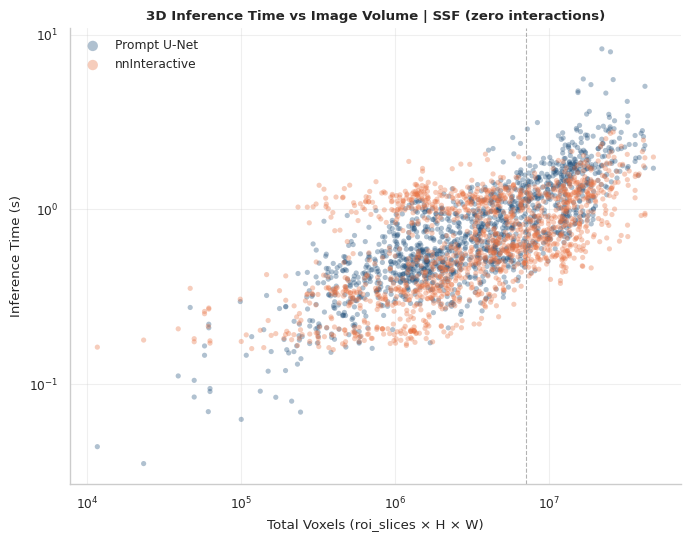

In [6]:
COLORS = {'P-UNet': '#1f4e79', 'nnInteractive': '#E87040'}
LABELS = {'P-UNet': 'Prompt U-Net', 'nnInteractive': 'nnInteractive'}

fig, ax = plt.subplots(figsize=(7, 5.5))

for mode, model in [('ssf', 'P-UNet'), ('baseline', 'nnInteractive')]:
    sub = df[(df['mode'] == mode) & (df['model'] == model)]
    sub_agg = sub.groupby(['volume_id', 'run_idx']).agg(
        time_s=('time_s', 'mean'), total_voxels=('total_voxels', 'first'))
    ax.scatter(sub_agg['total_voxels'], sub_agg['time_s'],
               alpha=0.35, s=14, color=COLORS[model], label=LABELS[model], edgecolors='none')

ax.axvline(PATCH_VOXELS, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Total Voxels (roi_slices × H × W)')
ax.set_ylabel('Inference Time (s)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('3D Inference Time vs Image Volume | SSF (zero interactions)', weight='bold')
ax.grid(alpha=0.3); ax.legend(frameon=False, markerscale=2)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('inference_speed_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

---
## §4 — Timing Table

In [7]:
nn_ifl_key = 'ifl_ssf' if 'ifl_ssf' in sorted(df[df['model'] == 'nnInteractive']['mode'].unique()) else 'ifl'

TIMING_MODES = [
    ('SSF (zero interactions)',        [('ssf', 'P-UNet'), ('baseline', 'nnInteractive')]),
    ('SSF & IFL (matched interactions)', [('ifl_ssf', 'P-UNet'), (nn_ifl_key, 'nnInteractive')]),
]

print(f"{'='*76}")
print(f"  Small = ROI in-plane bbox ≤ 128   (P-UNet single-tile regime)")
print(f"  Large = total_voxels > {PATCH_VOXELS:,}  (nnInteractive AutoZoom)")
print(f"{'='*76}")

for comparison_label, mode_pairs in TIMING_MODES:
    print(f"\n  ── {comparison_label} ──")
    print(f"  {'Size':<16} {'Model':<20} {'n':<6} {'Time (s)':<20}")
    print(f"  {'-'*62}")
    for size_bin in ['Small', 'Large']:
        for mode, model in mode_pairs:
            sub = df[(df['size_bin'] == size_bin) & (df['mode'] == mode) & (df['model'] == model)]
            times = sub.drop_duplicates(subset=['volume_id', 'run_idx'])['time_s']
            display_name = 'Prompt U-Net' if model == 'P-UNet' else 'nnInteractive'
            print(f"  {size_bin:<16} {display_name:<20} {len(times):<6} {times.mean():.2f} ± {times.std():.2f}")

for extra_bin in ['Medium', 'Small & Large']:
    sub = df[df['size_bin'] == extra_bin]
    if len(sub) > 0:
        n = len(sub.drop_duplicates(subset=['volume_id', 'run_idx']))
        print(f"\n  ({extra_bin}: {n} runs not shown above — see appendix)")

print(f"\n{'='*76}")

  Small = ROI in-plane bbox ≤ 128   (P-UNet single-tile regime)
  Large = total_voxels > 7,077,888  (nnInteractive AutoZoom)

  ── SSF (zero interactions) ──
  Size             Model                n      Time (s)            
  --------------------------------------------------------------
  Small            Prompt U-Net         899    0.59 ± 0.30
  Small            nnInteractive        899    0.62 ± 0.39
  Large            Prompt U-Net         188    1.81 ± 0.94
  Large            nnInteractive        188    1.18 ± 0.47

  ── SSF & IFL (matched interactions) ──
  Size             Model                n      Time (s)            
  --------------------------------------------------------------
  Small            Prompt U-Net         899    0.65 ± 0.32
  Small            nnInteractive        899    0.76 ± 0.52
  Large            Prompt U-Net         188    1.91 ± 0.63
  Large            nnInteractive        188    1.66 ± 0.82

  (Medium: 96 runs not shown above — see appendix)

  (Small 

---
## §5 — Memory Reference (nnInteractive Paper Values)

From the nnInteractive paper (Section A5, Table A3):
- **Small objects** (≤192³): <6 GB VRAM, 120–200 ms on RTX 4090
- **Large objects** (>192³, AutoZoom): <10 GB VRAM, up to 3500 ms on RTX 4090

Prompt U-Net VRAM is measured separately in `p_unet_memory.ipynb`.

In [8]:
print(f"{'='*64}")
print(f"  VRAM Reference")
print(f"{'='*64}")
print(f"  {'Model':<22} {'Small':<18} {'Large':<18}")
print(f"  {'-'*58}")
print(f"  {'Prompt U-Net':<22} {'see p_unet_memory.ipynb':<18} {'see p_unet_memory.ipynb':<18}")
print(f"  {'nnInteractive':<22} {'< 6 GB':<18} {'< 10 GB':<18}")
print(f"{'='*64}")

  VRAM Reference
  Model                  Small              Large             
  ----------------------------------------------------------
  Prompt U-Net           see p_unet_memory.ipynb see p_unet_memory.ipynb
  nnInteractive          < 6 GB             < 10 GB           


---
## Appendix — Per-Dataset Timing Detail

In [9]:
detail_rows = []
for ds in sorted(df['dataset_name'].unique()):
    for size_bin in ['Small', 'Medium', 'Large', 'Small & Large']:
        sub = df[(df['dataset_name'] == ds) & (df['size_bin'] == size_bin)]
        if len(sub) == 0:
            continue
        n = len(sub.drop_duplicates(subset=['volume_id', 'run_idx']))
        bbox_mean = sub['max_bbox_extent'].iloc[0] if len(sub) else 0
        tv_mean = sub['total_voxels'].iloc[0] if len(sub) else 0
        detail_rows.append({
            'Dataset': ds, 'Size': size_bin, 'n_runs': n,
            'bbox_extent_mean': f'{bbox_mean:.0f}',
            'total_voxels_mean': f'{tv_mean:,.0f}',
        })

df_detail = pd.DataFrame(detail_rows)
display(df_detail.set_index(['Dataset', 'Size']))

n_runs bbox_extent_mean total_voxels_mean
Dataset      Size                                                    
FLARE_2022   Small              78               35         6,301,680
             Medium             16              222         4,428,432
             Large              22              130         9,558,432
             Small & Large      84               75         7,114,800
HCCTase_ceCT Small              59               29         2,333,352
             Medium              1              169         2,181,568
             Large              76              165        22,100,544
             Small & Large      20              117        15,518,400
SegRap2023   Small             103               10         1,227,582
             Large               7              154        27,775,160
             Small & Large      50               88        18,145,230
TotalSeg_mri Small             349                7         1,289,340
             Medium             66              134         6,598,350
             Large              82              212        23,494,640
             Small & Large      83               48        32,638,144
han_seg_ct   Small             151               14         1,548,384
             Medium              9              141         3,873,936
             Small & Large       8               37         7,258,050
han_seg_mri  Small             159               80         4,935,474
             Medium              4              224         1,838,706
             Large               1              134         8,590,032
             Small & Large       4               19        32,516,064